<a href="https://colab.research.google.com/github/hwayoungc24-rgb/younghwa/blob/main/abalone_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

In [8]:
# 데이터 로딩
file_path = '/content/drive/MyDrive/Colab Notebooks/abalone.csv'
df = pd.read_csv(file_path, index_col=0)

df

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
id,,,,,,,,,
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9


In [9]:
from sklearn.model_selection import train_test_split

# df 데이터를 8:2로 나누기
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# df_train과 df_test를 확인할 수 있습니다.
print("Training data size:", df_train.shape)
print("Test data size:", df_test.shape)

Training data size: (3341, 9)
Test data size: (836, 9)


In [10]:
df_train.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
id,,,,,,,,,
4038,I,0.550,0.445,0.125,0.6720,0.2880,0.1365,0.210,11
1272,I,0.475,0.355,0.100,0.5035,0.2535,0.0910,0.140,8
3384,F,0.305,0.225,0.070,0.1485,0.0585,0.0335,0.045,7
3160,I,0.275,0.200,0.065,0.1165,0.0565,0.0130,0.035,7
3894,M,0.495,0.380,0.135,0.6295,0.2630,0.1425,0.215,12


In [11]:
print(df_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3341 entries, 4038 to 860
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             3341 non-null   object 
 1   Length          3341 non-null   float64
 2   Diameter        3341 non-null   float64
 3   Height          3341 non-null   float64
 4   Whole_weight    3341 non-null   float64
 5   Shucked_weight  3341 non-null   float64
 6   Viscera_weight  3341 non-null   float64
 7   Shell_weight    3341 non-null   float64
 8   Rings           3341 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 261.0+ KB
None


In [12]:
df_train.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,3341.000000,3341.000000,3341.000000,3341.000000,3341.000000,3341.000000,3341.000000,3341.000000
mean,0.524964,0.408518,0.139790,0.830838,0.360561,0.180832,0.239682,9.944627
std,0.119137,0.098687,0.042514,0.491583,0.223018,0.109444,0.139941,3.207344
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.443000,0.186500,0.093000,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.802000,0.337000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.151000,0.503500,0.253500,0.328500,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [13]:
def plot_numerics(data):
    numeric_columns = data.columns
    # Plotting histograms and box plots for each numeric column
    for column in numeric_columns:
        _, ax = plt.subplots(1,2, figsize=(16, 5))
        ax=ax.flatten()

        # Histogram
        sns.histplot(data[column], bins=50, kde=True, color='skyblue', ax=ax[0])
        ax[0].set_title(f'Histogram of {column}', fontsize=15,fontweight='bold')
        ax[0].set_xlabel(column, fontsize=12)
        ax[0].set_ylabel('Frequency', fontsize=12)

        # Box plot
        sns.boxplot(x=data[column], color='lightgreen', ax=ax[1])
        ax[1].set_title(f'Box plot of {column}', fontsize=15,fontweight='bold')
        ax[1].set_xlabel(column, fontsize=12)

        plt.tight_layout()
        plt.show()

def get_count_plot(cat):
    ax=sns.countplot(x=df_train[cat],
                   order=df_train[cat].value_counts(ascending=False).index);

    abs_values = df_train[cat].value_counts(ascending=False)
    rel_values = df_train[cat].value_counts(ascending=False, normalize=True).values * 100
    lbls = [f'{p[0]} ({p[1]:.0f}%)' for p in zip(abs_values, rel_values)]

    ax.bar_label(container=ax.containers[0], labels=lbls)
    ax.set_title("Distribution of "+cat+" Values",fontsize=16)

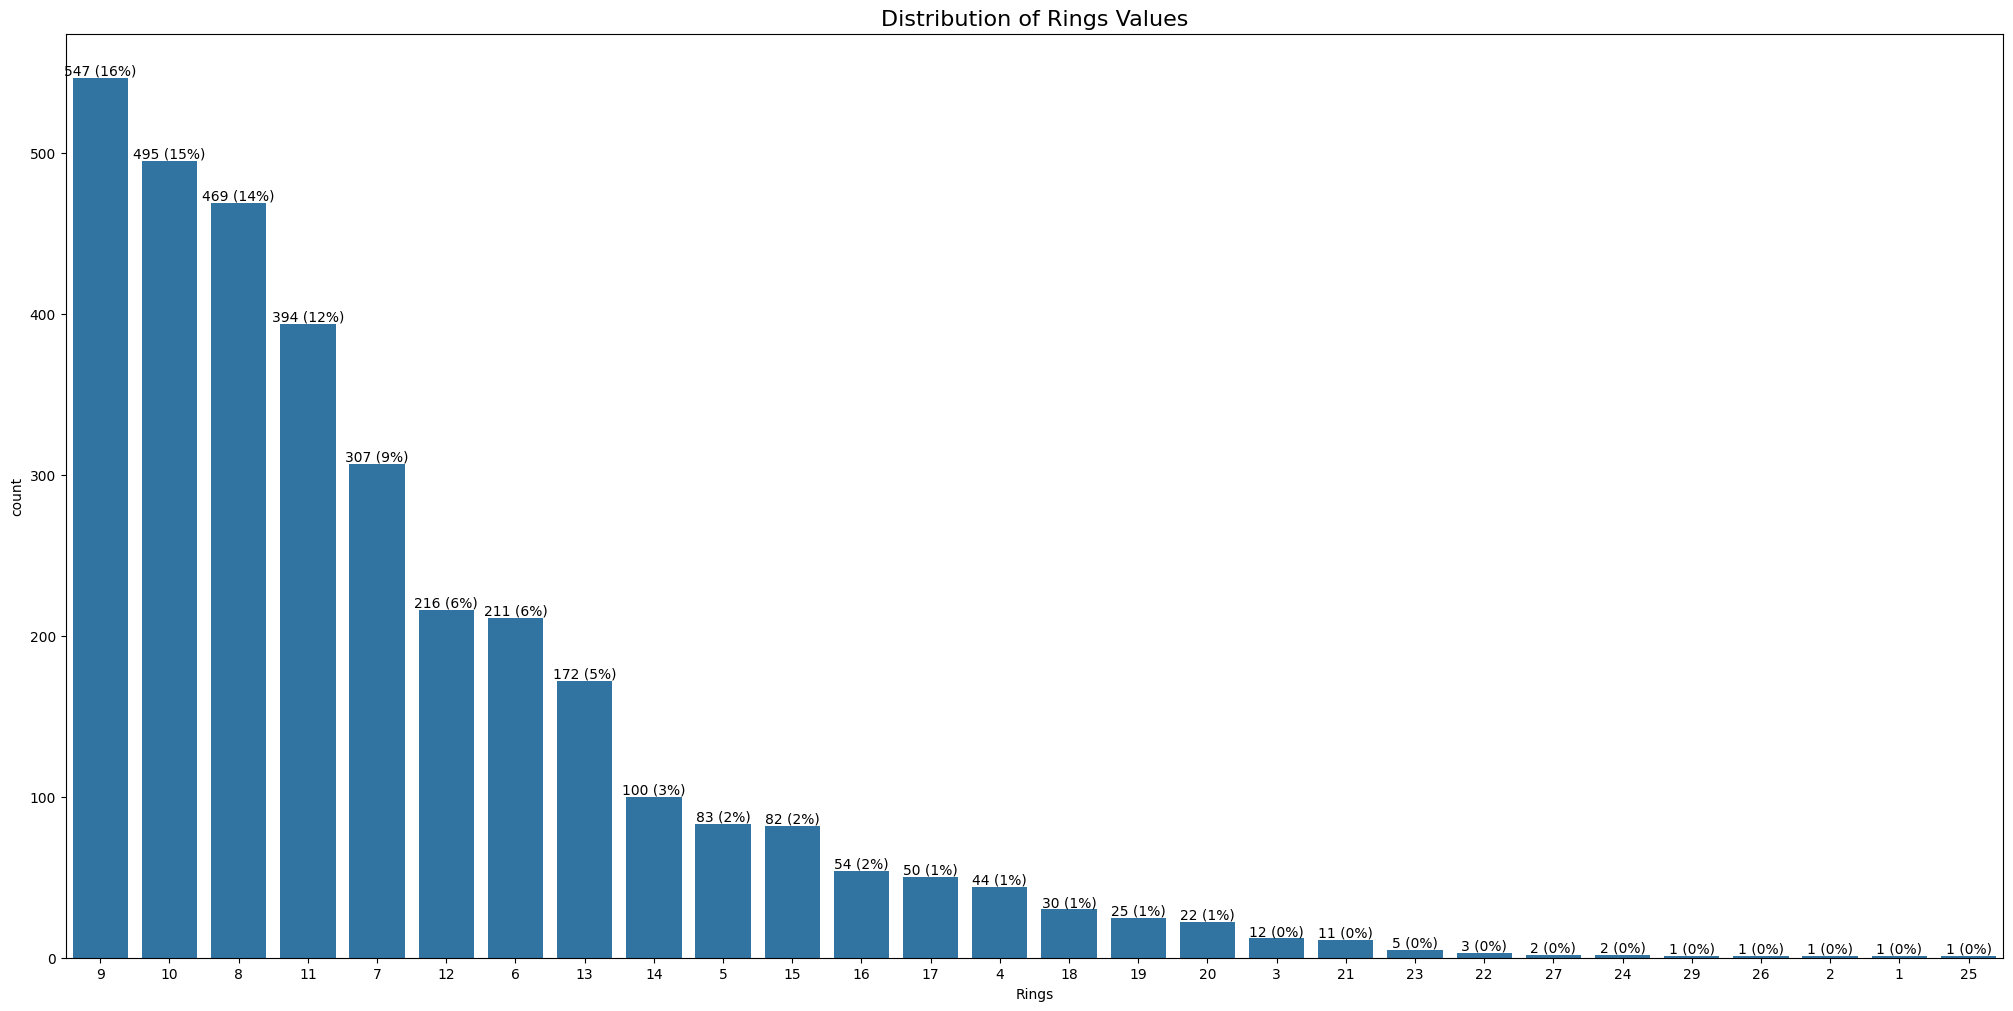

In [14]:
plt.figure(figsize=(25, 12))
get_count_plot('Rings')

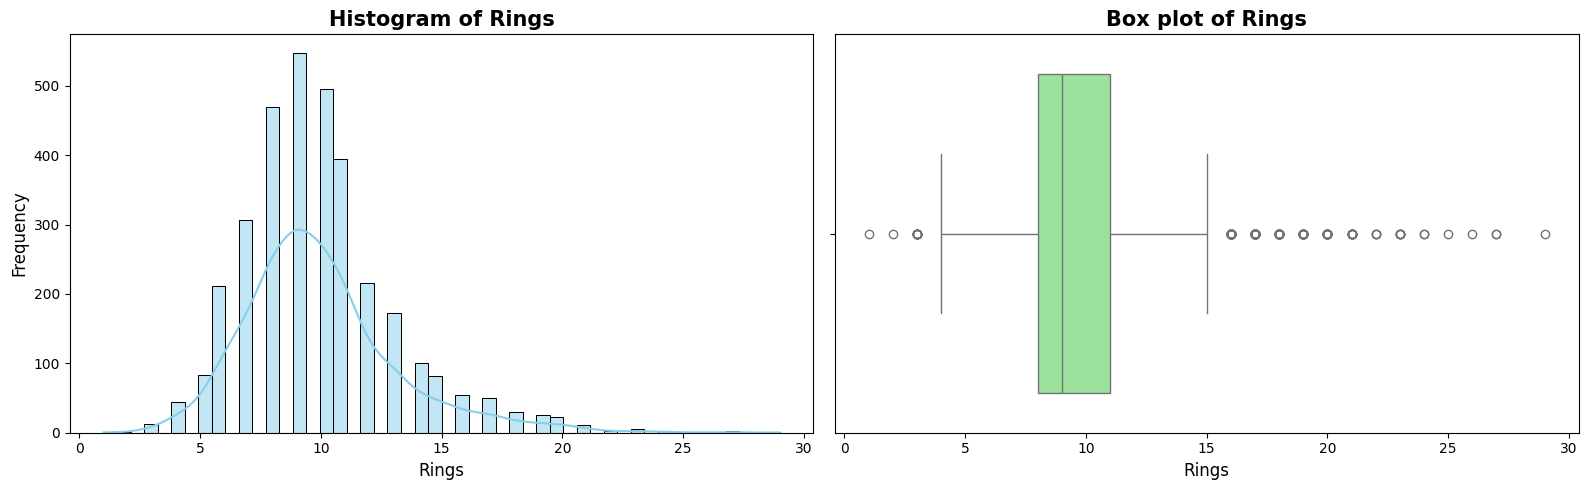

In [15]:
plot_numerics(df_train[['Rings']])

In [16]:
df_train.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

In [17]:
df_train["Whole weight Ratio"] = df_train["Shucked_weight"] / df_train["Whole_weight"]

In [18]:
df_train

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Whole weight Ratio
id,,,,,,,,,,
4038,I,0.550,0.445,0.125,0.6720,0.2880,0.1365,0.210,11,0.428571
1272,I,0.475,0.355,0.100,0.5035,0.2535,0.0910,0.140,8,0.503476
3384,F,0.305,0.225,0.070,0.1485,0.0585,0.0335,0.045,7,0.393939
3160,I,0.275,0.200,0.065,0.1165,0.0565,0.0130,0.035,7,0.484979
3894,M,0.495,0.380,0.135,0.6295,0.2630,0.1425,0.215,12,0.417792
...,...,...,...,...,...,...,...,...,...,...
3444,F,0.490,0.400,0.115,0.5690,0.2560,0.1325,0.145,9,0.449912
466,F,0.670,0.550,0.190,1.3905,0.5425,0.3035,0.400,12,0.390147
3092,M,0.510,0.395,0.125,0.5805,0.2440,0.1335,0.188,11,0.420327


In [19]:
cat_cols=['Sex']
num_cols=['Length', 'Diameter', 'Height',
             'Whole_weight','Shucked_weight',
             'Viscera_weight', 'Shell_weight', "Whole weight Ratio"]

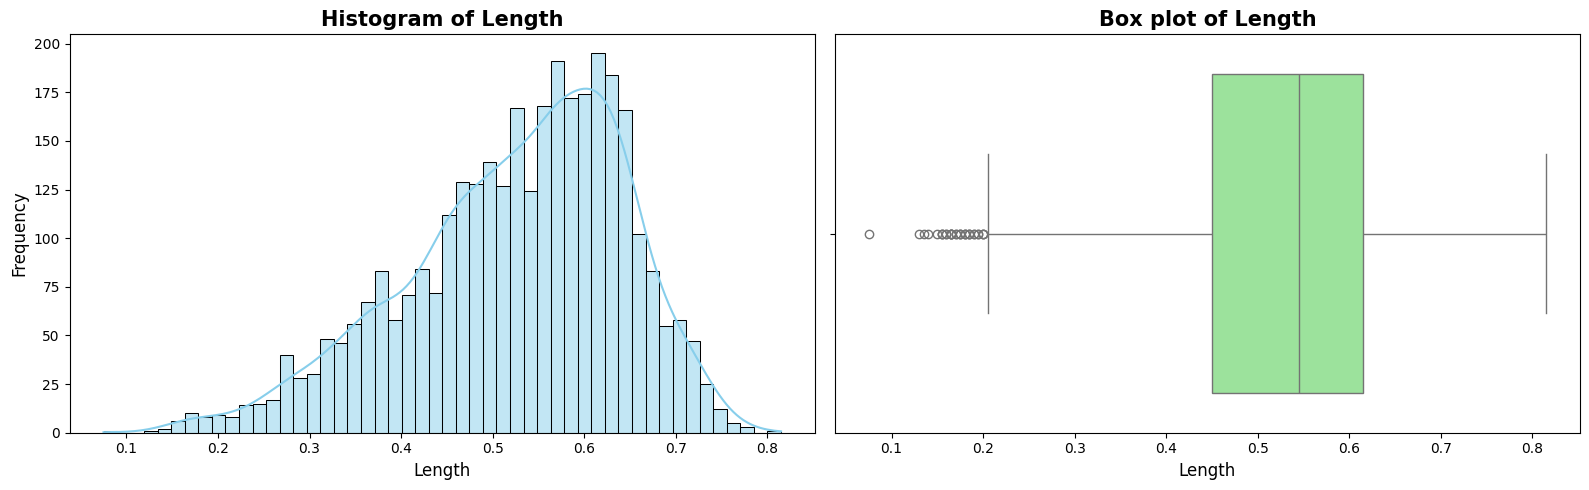

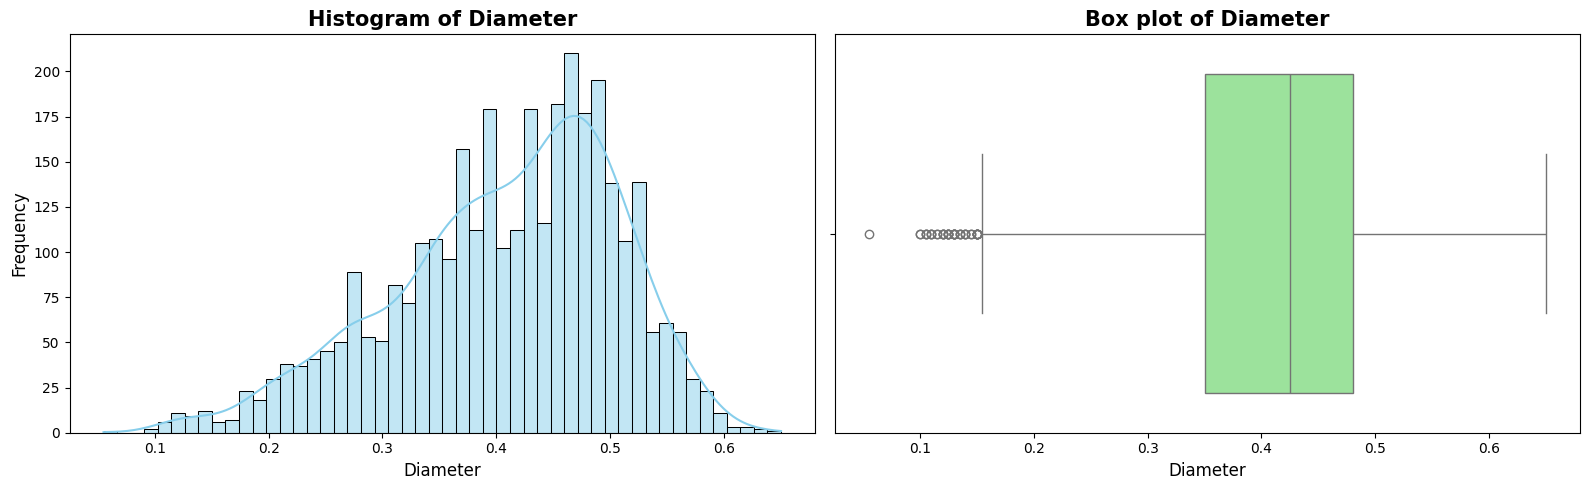

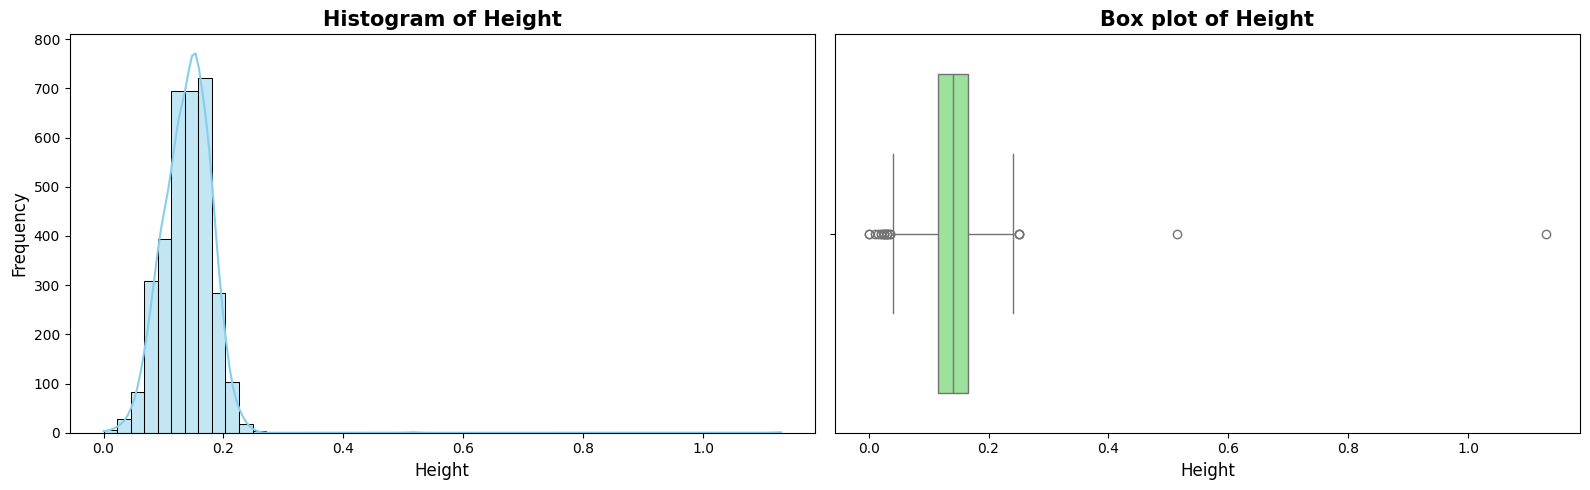

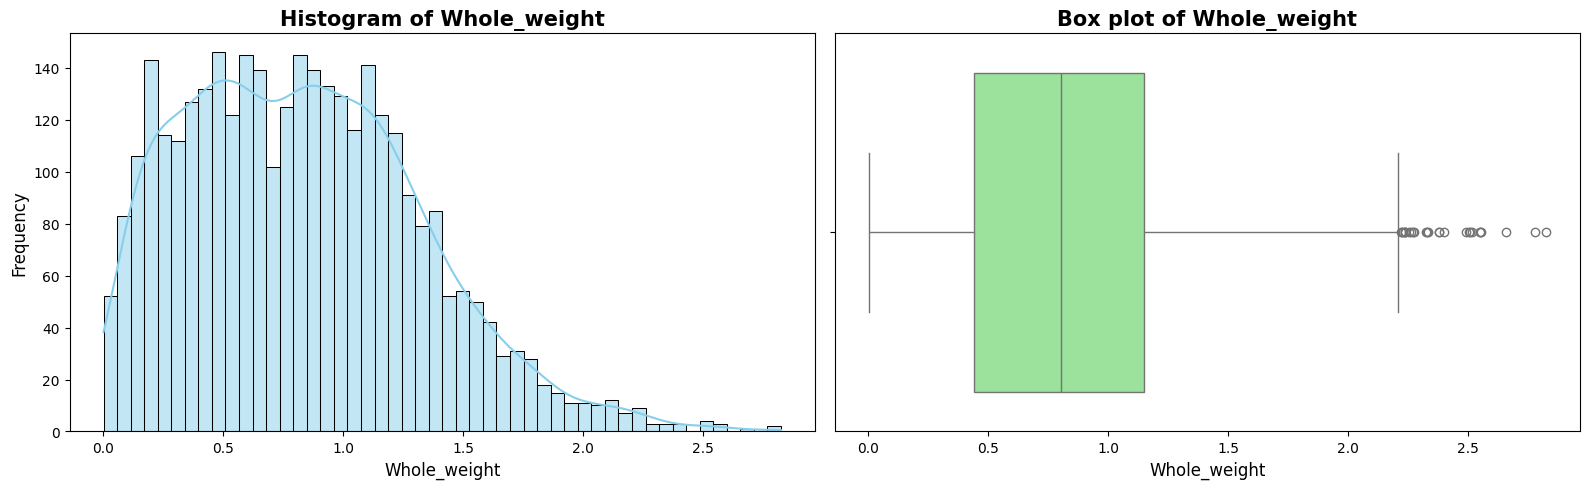

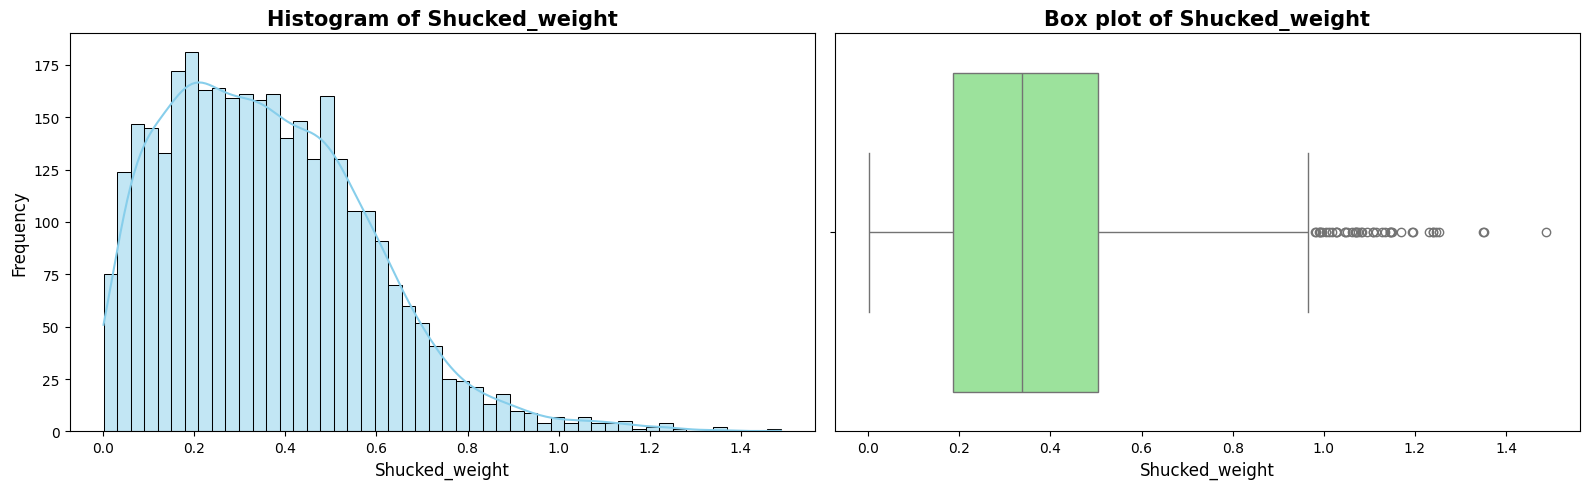

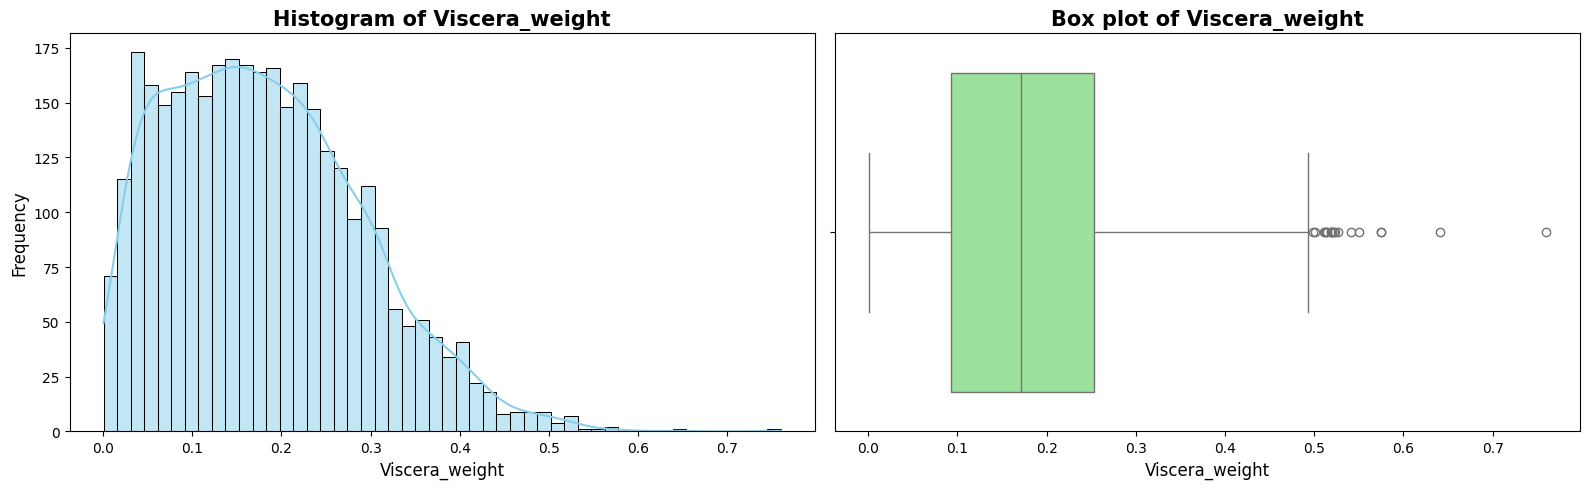

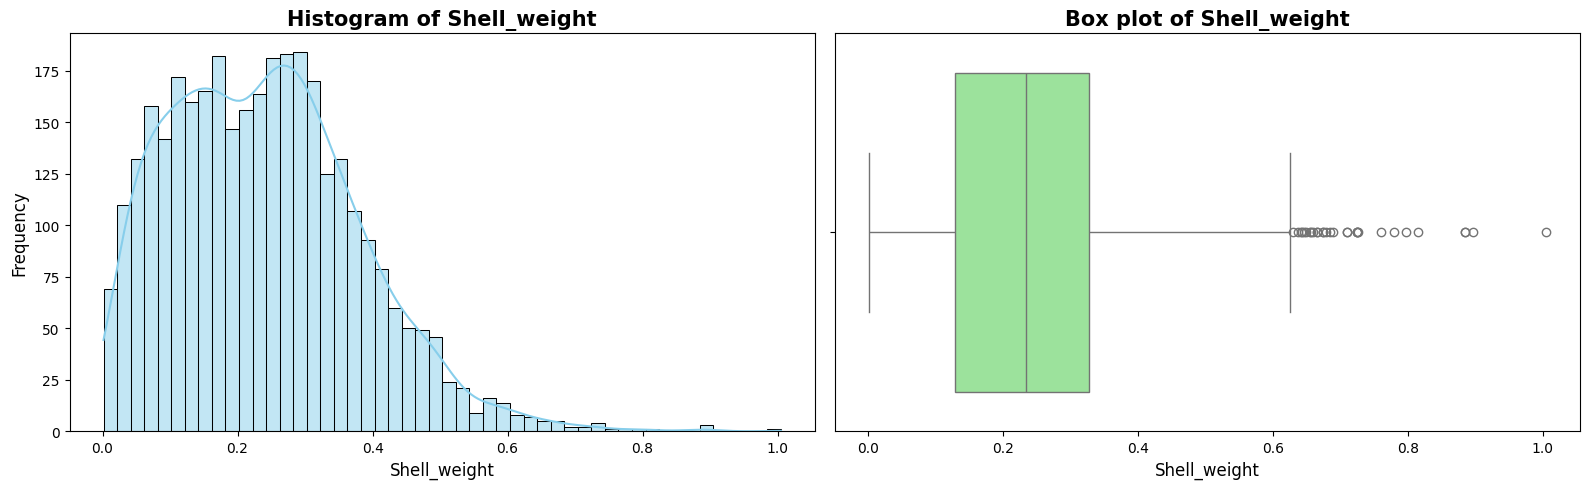

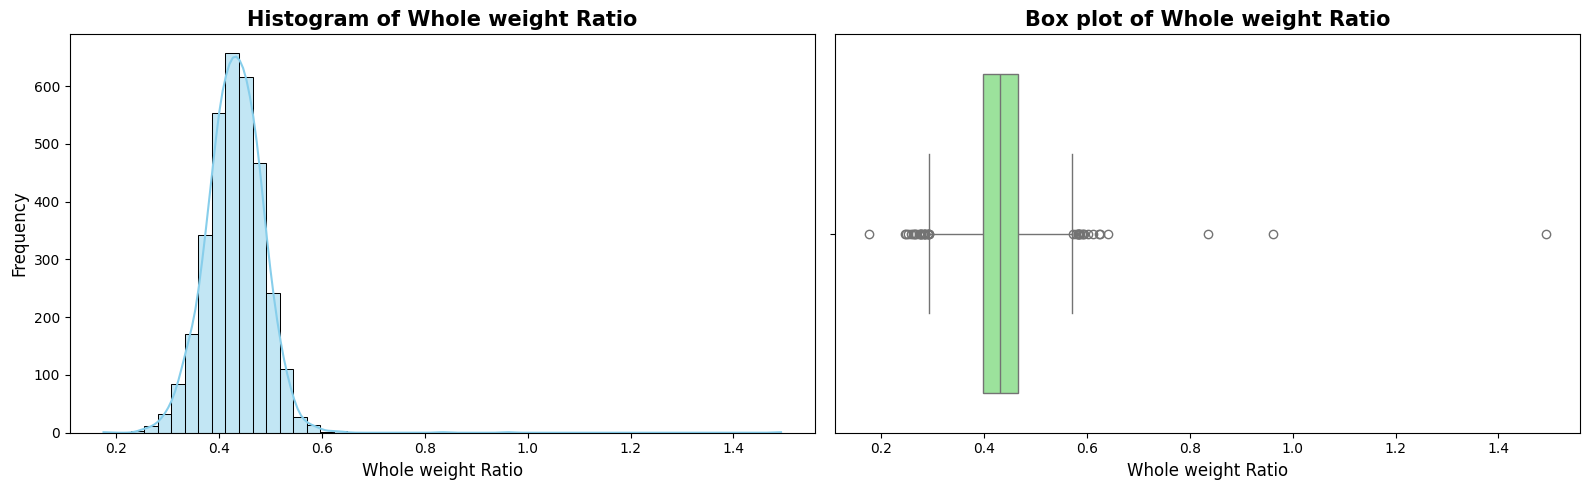

In [20]:
plot_numerics(df_train[num_cols])

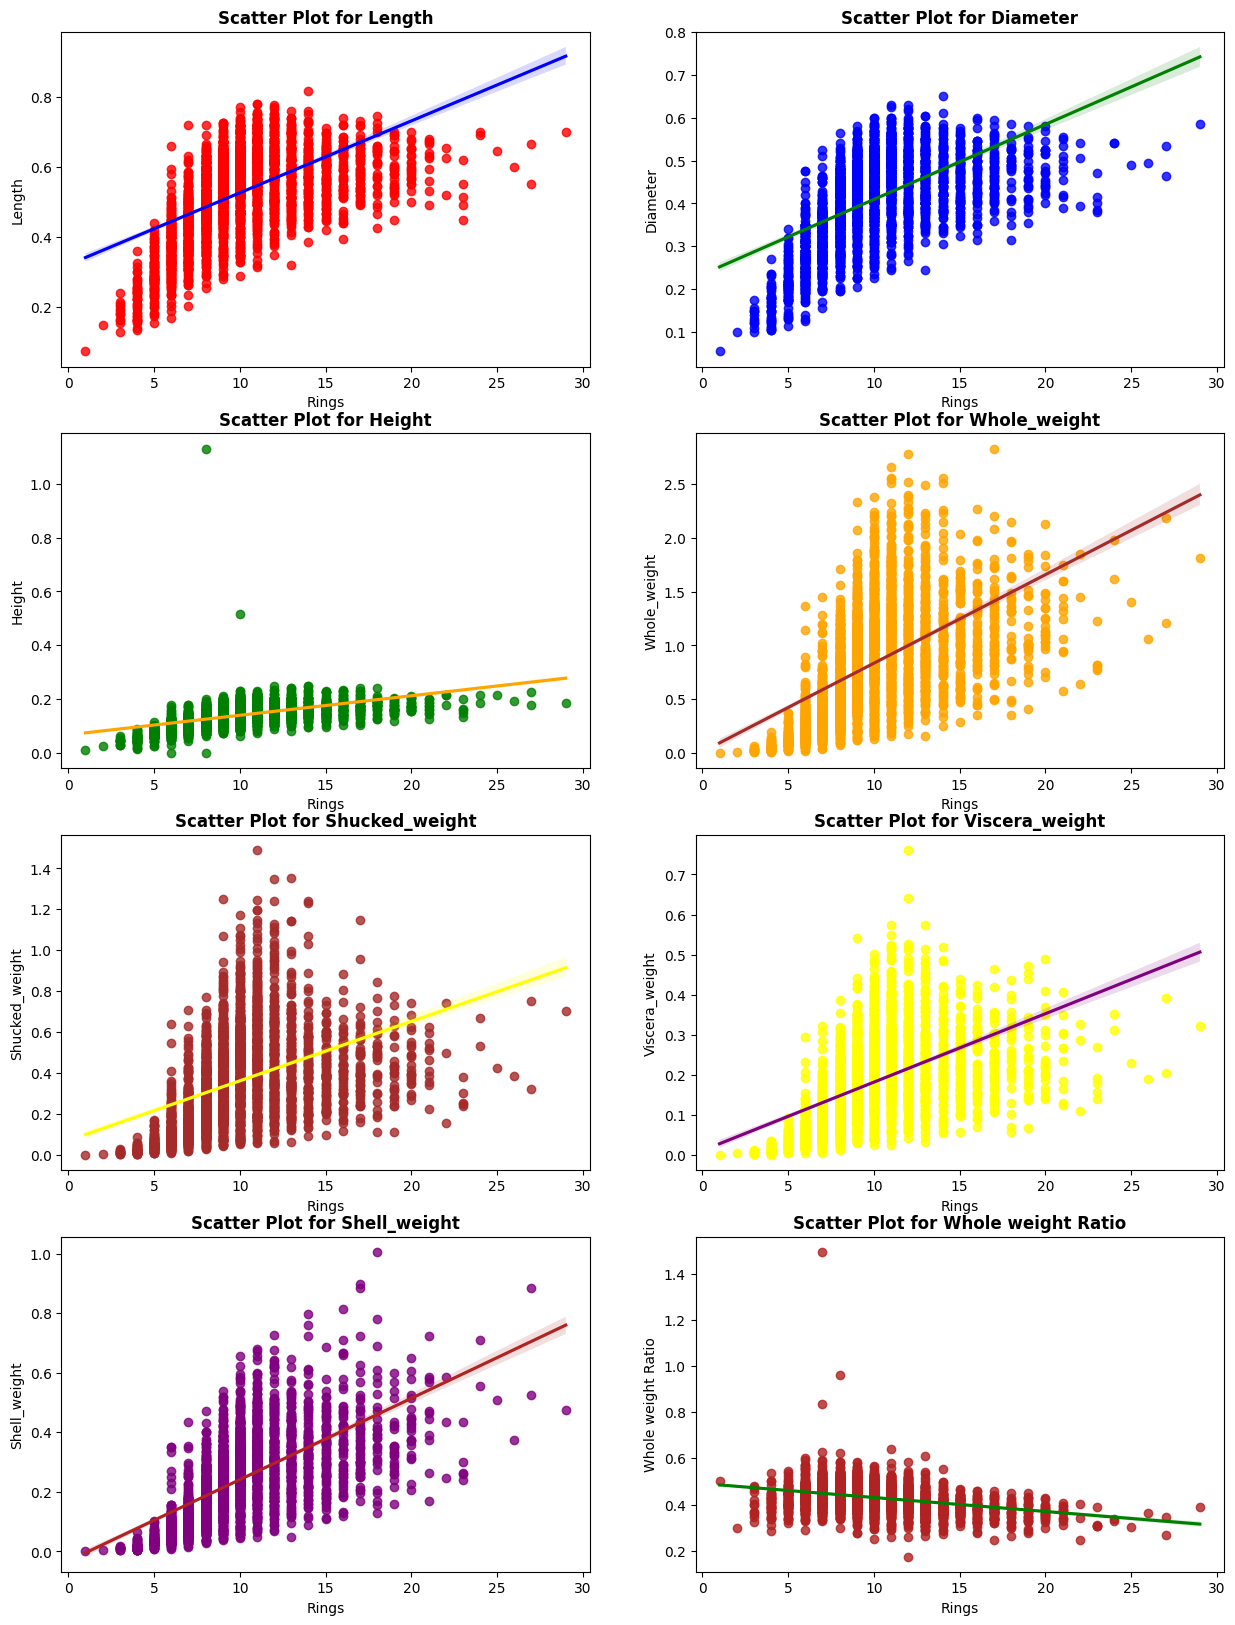

In [21]:
# Determine the size of the grid
n_cols = 2  # Number of columns in the subplot grid
n_rows = int(np.ceil(len(num_cols) / n_cols))  # Calculate the number of rows needed
#
fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axs = axs.flatten() if n_rows > 1 else [axs]
#
colors=['red','blue','green','orange','brown','yellow','purple','firebrick','green']
for i, ncol in enumerate(num_cols):
    sns.regplot(data=df_train, x="Rings", y=ncol, ax=axs[i],
                color=colors[i],line_kws=dict(color=colors[i+1]))
    axs[i].set_title(f'Scatter Plot for {ncol}',fontweight='bold')

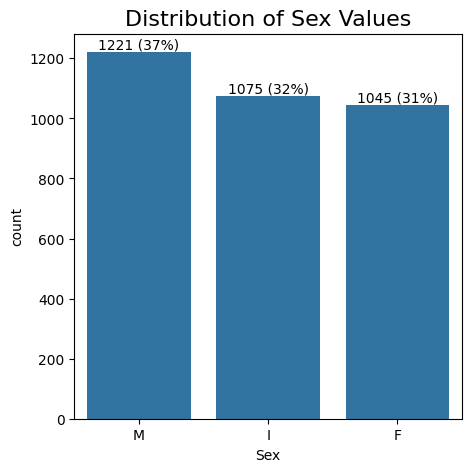

In [22]:
plt.figure(figsize=(5, 5))
get_count_plot('Sex')

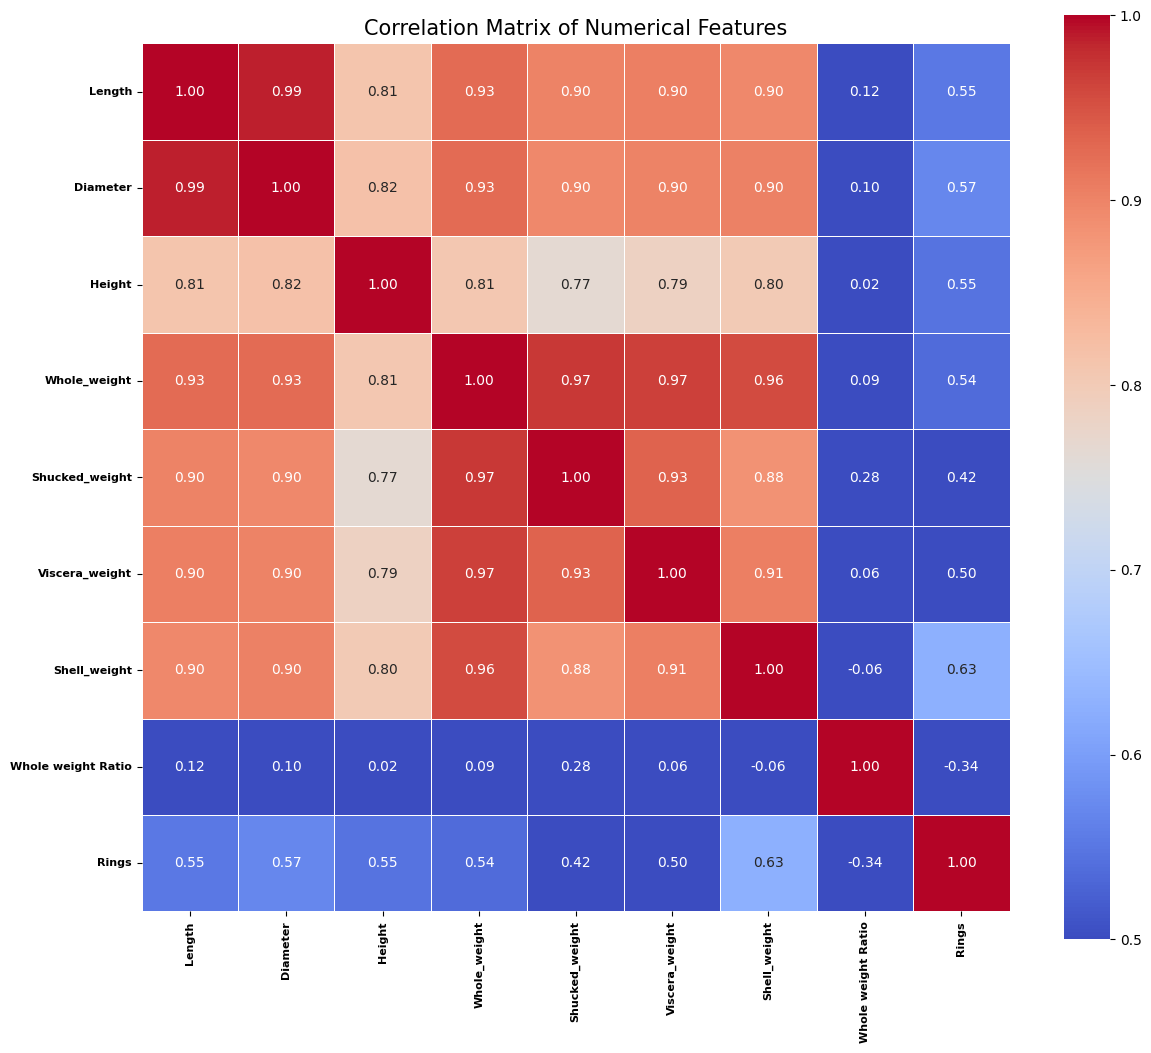

In [23]:
corr_matrix = df_train[num_cols+['Rings']].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, vmax=1, vmin=0.5, center=0.75,annot=True, fmt=".2f", square=True,
            linewidths=.5, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features', fontsize=15)
plt.xticks(fontsize=8,fontweight='bold')
plt.yticks(fontsize=8,fontweight='bold')
plt.show()

In [24]:
num_cols=['Length','Diameter','Height',"Whole weight Ratio"]

In [25]:
def getFeats(df):

    df["Whole weight Ratio"]=df["Shucked_weight"]/df["Whole_weight"]
    df["Shell_weight"]=np.log(0.00001+df["Shell_weight"])
    df["Whole_weight"]=np.log(0.00001+df["Whole_weight"])
    df["Shucked_weight"]=np.log(0.00001+df["Shucked_weight"])
    df["Viscera_weight"]=np.log(0.00001+df["Viscera_weight"])

    sex_dict={'I':0,'M':1,'F':2}
    df['Sex']=df['Sex'].map(sex_dict)

    scaler = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])

    return df

In [26]:
df_train['typ']=0
df_test['typ']=1
#
df_all=pd.concat([df_train,df_test],axis=0)
df_all=getFeats(df_all)
df_all.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Whole weight Ratio,typ
id,,,,,,,,,,,
4038,0,0.216591,0.374075,-0.347099,-0.397482,-1.244760,-1.991357,-1.560600,11,-0.036338,0
1272,0,-0.408000,-0.532927,-0.944870,-0.686152,-1.372352,-2.396786,-1.966041,8,0.671962,0
3384,2,-1.823741,-1.843041,-1.662195,-1.907103,-2.838558,-3.395911,-3.100871,7,-0.363821,0
3160,0,-2.073577,-2.094986,-1.781749,-2.149778,-2.873338,-4.342037,-3.352122,7,0.497052,0
3894,1,-0.241443,-0.280982,-0.107991,-0.462814,-1.335563,-1.948343,-1.537071,12,-0.138270,0


In [27]:
df_all['Rings'].value_counts()

,count
Rings,
9,689
10,634
8,568
11,487
7,391
12,267
6,259
13,203
14,126


In [28]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder를 사용하여 숫자로 인코딩
label_encoder = LabelEncoder()
df_all['Rings'] = label_encoder.fit_transform(df_all['Rings'])

In [29]:
df_all['Rings'].value_counts()

,count
Rings,
8,689
9,634
7,568
10,487
6,391
11,267
5,259
12,203
13,126


In [33]:
print(df_train.columns)
print(df_test.columns)

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings', 'Whole weight Ratio', 'typ'],
      dtype='object')
Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings', 'Whole weight Ratio', 'typ'],
      dtype='object')


In [34]:
# 필요한 라이브러리 임포트
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# 데이터 준비
df_train = df_all[df_all['typ'] == 0]
df_test = df_all[df_all['typ'] == 1]

# 피처와 타겟 설정
X_train = df_train.drop(['Rings', 'typ'], axis=1)
y_train = df_train['Rings']
X_test = df_test.drop(['Rings', 'typ'], axis=1)
y_test = df_test['Rings']

# 훈련과 검증 데이터로 분리 (옵션)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
# RandomForestClassifier 모델 생성
rf = RandomForestClassifier(random_state=42)

# 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 200, 500],        # 트리의 개수
    'max_depth': [None, 10, 20, 30],        # 트리의 최대 깊이
    'min_samples_split': [2, 5, 10],        # 내부 노드를 분할하는 데 필요한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4],          # 리프 노드에 있어야 하는 최소 샘플 수
    'max_features': ['auto', 'sqrt', 'log2'], # 각 트리에서 사용할 피처의 수
    'bootstrap': [True, False]              # 배깅 샘플링 여부
}

# GridSearchCV를 사용한 하이퍼파라미터 튜닝
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           scoring='accuracy', cv=3, verbose=1, n_jobs=-1)

# 모델 학습
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print(f"Best Hyperparameters: {grid_search.best_params_}")

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


In [ ]:
# 최적의 모델로 테스트 데이터 예측
y_pred = grid_search.predict(X_test)

# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# 추가 평가 지표 출력 (classification report)
print(classification_report(y_test, y_pred))